<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/11_General_Linear_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: General Linear Models and Least Squares

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Materi
General Linear Models (GLM) adalah kerangka kerja statistik yang luas di mana variabel target dinyatakan sebagai kombinasi linear dari variabel prediktor. Jika *Least Squares* sederhana hanya mencari garis lurus, GLM memungkinkan kita memasukkan variabel prediktor yang lebih kompleks (seperti variabel kategorikal atau interaksi antar fitur) ke dalam sistem linear yang sama.

### Topik yang Dibahas:
1. Terminologi GLM (Target, Prediktor, Parameter)
2. Menyiapkan Model GLM dalam Matriks
3. Geometri Proyeksi Least Squares
4. Implementasi dengan QR Decomposition


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data untuk GLM
# Kita akan memodelkan y = b0 + b1*x1 + b2*x2 + noise
np.random.seed(42)
N = 100
x1 = np.random.randn(N)
x2 = np.random.randn(N)
y = 2 + 0.5*x1 + 1.5*x2 + np.random.normal(0, 0.5, N)

# Matriks desain X: [1, x1, x2]
X = np.column_stack((np.ones(N), x1, x2))

# 2. Menyelesaikan GLM menggunakan Persamaan Normal
b = np.linalg.inv(X.T @ X) @ X.T @ y
print("Parameter Model (b0, b1, b2):", b)


Parameter Model (b0, b1, b2): [2.04432434 0.61304468 1.49386161]


***
## Geometri Proyeksi Least Squares

### Penjelasan Teori
Mengapa Least Squares berhasil meminimalkan error? Secara geometris, karena kita memproyeksikan vektor target **y** ke ruang kolom yang direntangkan oleh kolom-kolom matriks **X**. Proyeksi ini menciptakan vektor **y_hat** (prediksi) yang sedekat mungkin dengan **y**. Perbedaan (error) antara **y** dan **y_hat** adalah residual yang tegak lurus terhadap ruang kolom **X**.



Hasil parameter dengan QR Decomposition: [2.04432434 0.61304468 1.49386161]


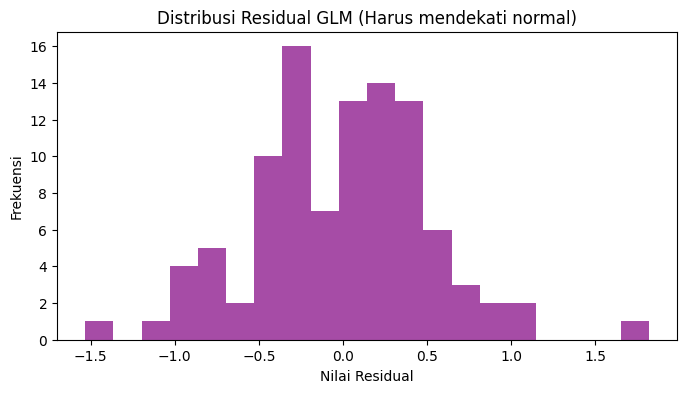

In [4]:
# 3. Implementasi Least Squares via QR
# QR lebih stabil secara numerik untuk matriks dengan korelasi tinggi
Q, R = np.linalg.qr(X)
b_qr = np.linalg.inv(R) @ Q.T @ y

print("Hasil parameter dengan QR Decomposition:", b_qr)

# Visualisasi Residual
y_pred = X @ b
residual = y - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residual, bins=20, color='purple', alpha=0.7)
plt.title('Distribusi Residual GLM (Harus mendekati normal)')
plt.xlabel('Nilai Residual')
plt.ylabel('Frekuensi')
plt.show()
